# 02. Edge Detection

목표는 색칠 경계로 사용할 선을 추출하고, 흰 배경과 검은 선 형태의 컬러링북 선화를 만드는 것입니다.

비교 알고리즘:

- Sobel: x/y 방향 밝기 변화량을 계산합니다.
- Laplacian: 2차 미분 기반으로 급격한 변화 지점을 찾습니다.
- Canny: 노이즈 제거, 그래디언트, 비최대 억제, 이중 임계값을 함께 사용하는 대표적인 경계 추출 방식입니다.
- Hybrid Color Boundary: Canny가 놓치는 비슷한 밝기의 색상 경계를 보완합니다.

최종 기본 알고리즘은 Canny에 색상 라벨 경계를 합친 Hybrid 방식입니다.

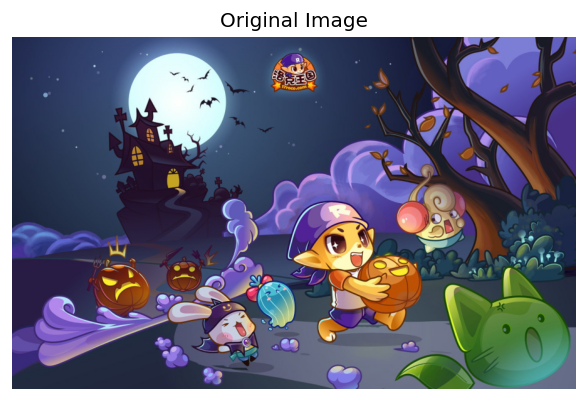

In [1]:
#Kernel → Restart & Run All 로 처음부터 실행하세요
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np

# 공통 함수가 들어 있는 src 폴더를 import 경로에 추가합니다.
sys.path.append("src")
import importlib
import coloringbook_utils as coloringbook_utils
importlib.reload(coloringbook_utils)
from coloringbook_utils import *

# 결과 저장 폴더(outputs)와 샘플 입력 폴더(data)를 생성합니다.
ensure_dirs()
plt.rcParams["figure.dpi"] = 120

# 직접 사용할 이미지가 있으면 여기에 경로를 넣으세요.
# 예: IMAGE_PATH = "../data/flowers.jpg"
IMAGE_PATH = "../data/ych.jpg"
if not IMAGE_PATH or not os.path.exists(IMAGE_PATH):
    print(f"WARNING: '{IMAGE_PATH}' not found, using built-in sample image instead.")
    IMAGE_PATH = None

try:
    image = load_image(IMAGE_PATH)
except FileNotFoundError as exc:
    print(f"WARNING: {exc}; using built-in sample image instead.")
    image = load_image(None)

show_images([("Original Image", image)], cols=1, figsize=(5, 5))

## 경계 추출 비교

먼저 K-Means로 색상을 단순화한 뒤 경계를 추출하면 원본의 작은 질감 노이즈가 줄어듭니다.

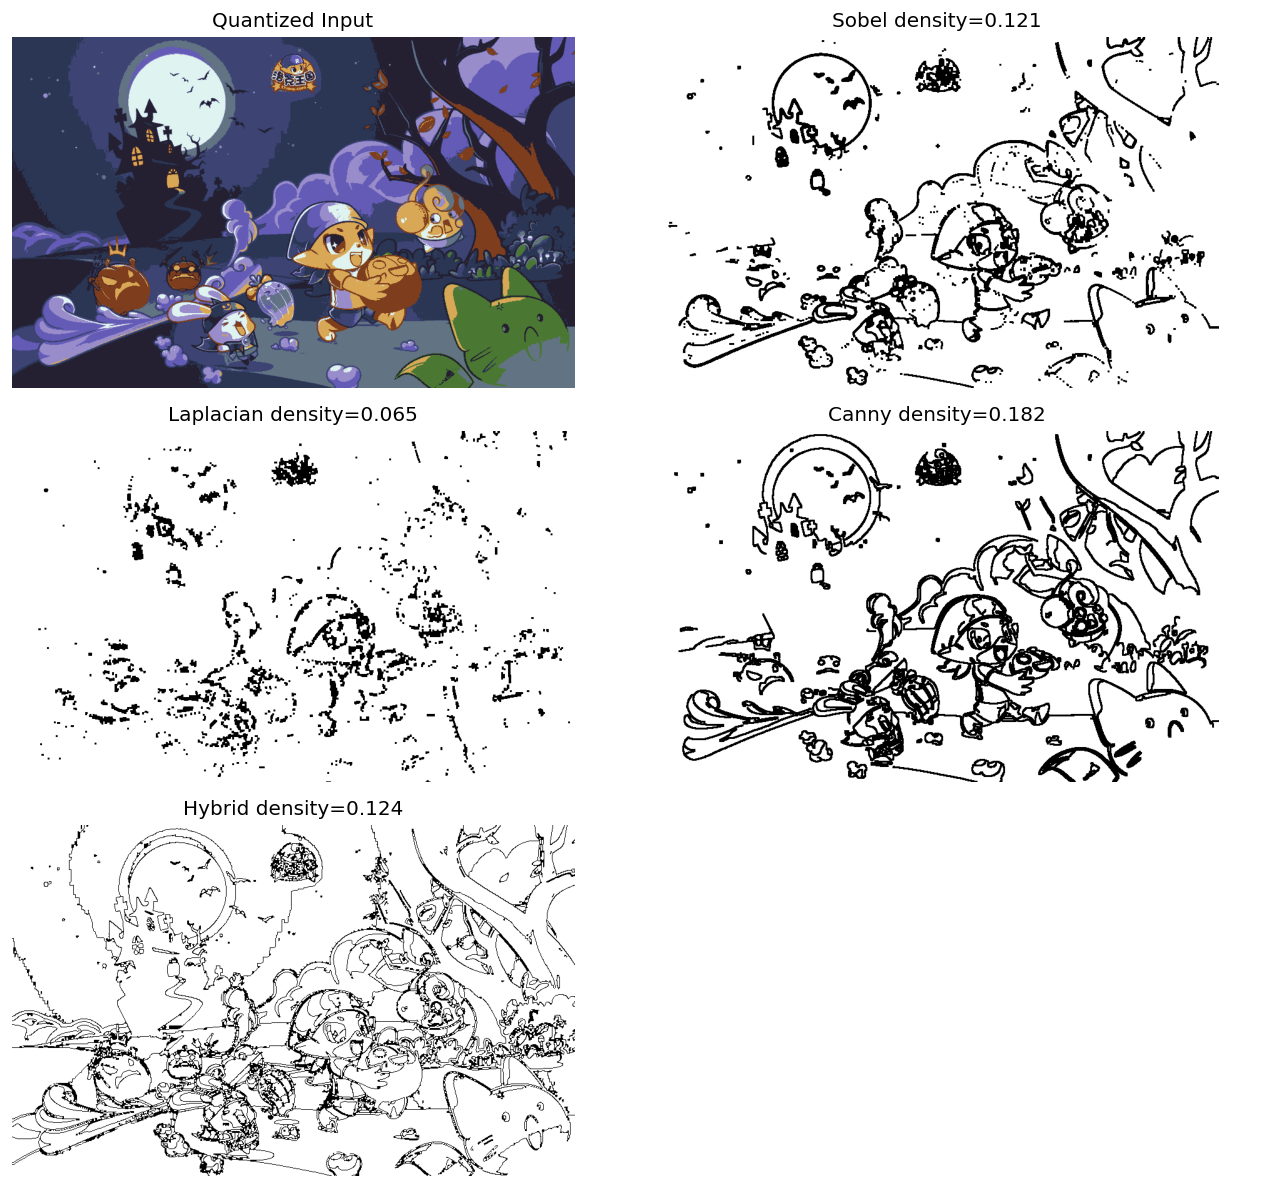

In [2]:
# 경계선 추출 전에 색상을 단순화하면 원본 텍스처 노이즈가 줄어듭니다.
K = 10
# Use existing helper if available, otherwise fall back to OpenCV k-means
if callable(globals().get("kmeans_quantization_with_labels")):
    quantized, palette, label_map = kmeans_quantization_with_labels(image, K)
else:
    Z = image.reshape(-1, 3).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1.0)
    _, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
    centers = np.clip(centers, 0, 255).astype(np.uint8)
    quantized = centers[labels.flatten()].reshape(image.shape)
    label_map = labels.reshape(image.shape[:2]).astype(np.int32)
    palette = centers

# Sobel: x/y 방향 밝기 변화량을 이용해 경계를 찾습니다.
(sobel, sobel_time) = timed_call(sobel_edges, quantized, 65)

# Laplacian: 2차 미분으로 급격한 밝기 변화를 찾습니다.
(laplacian, lap_time) = timed_call(laplacian_edges, quantized, 25)

# Canny: 노이즈 제거, 비최대 억제, 이중 임계값을 사용하는 기본 선택 알고리즘입니다.
(canny, canny_time) = timed_call(canny_edges, quantized, 60, 150)

# Color Boundary: K-Means 대표 색상 라벨이 바뀌는 지점을 경계로 추가합니다.
# 밝기는 비슷하지만 색상이 다른 겹친 영역을 분리하는 데 중요합니다.
(hybrid, hybrid_time) = timed_call(hybrid_canny_color_edges, quantized, 60, 150, label_map)

# Opening은 작은 점 노이즈 제거, Closing은 끊긴 선 연결에 사용합니다.
sobel_clean = clean_edges(sobel, open_iter=1, close_iter=1, thickness=1)
lap_clean = clean_edges(laplacian, open_iter=1, close_iter=1, thickness=1)
canny_clean = clean_edges(canny, open_iter=0, close_iter=1, thickness=2)
hybrid_clean = clean_edges(hybrid, open_iter=0, close_iter=1, thickness=1)

save_image_rgb("flowersoutput/02_sobel_lines.png", coloring_line_image(sobel_clean))
save_image_rgb("flowersoutput/02_laplacian_lines.png", coloring_line_image(lap_clean))
save_image_rgb("flowersoutput/02_canny_lines.png", coloring_line_image(canny_clean))
save_image_rgb("flowersoutput/02_hybrid_color_boundary_lines.png", coloring_line_image(hybrid_clean))

show_images([
    ("Quantized Input", quantized),
    (f"Sobel density={edge_density(sobel_clean):.3f}", coloring_line_image(sobel_clean)),
    (f"Laplacian density={edge_density(lap_clean):.3f}", coloring_line_image(lap_clean)),
    (f"Canny density={edge_density(canny_clean):.3f}", coloring_line_image(canny_clean)),
    (f"Hybrid density={edge_density(hybrid_clean):.3f}", coloring_line_image(hybrid_clean)),
], cols=2, figsize=(11, 10), cmap="gray", save_path="flowersoutput/02_edge_compare.png")

<class 'numpy.ndarray'>


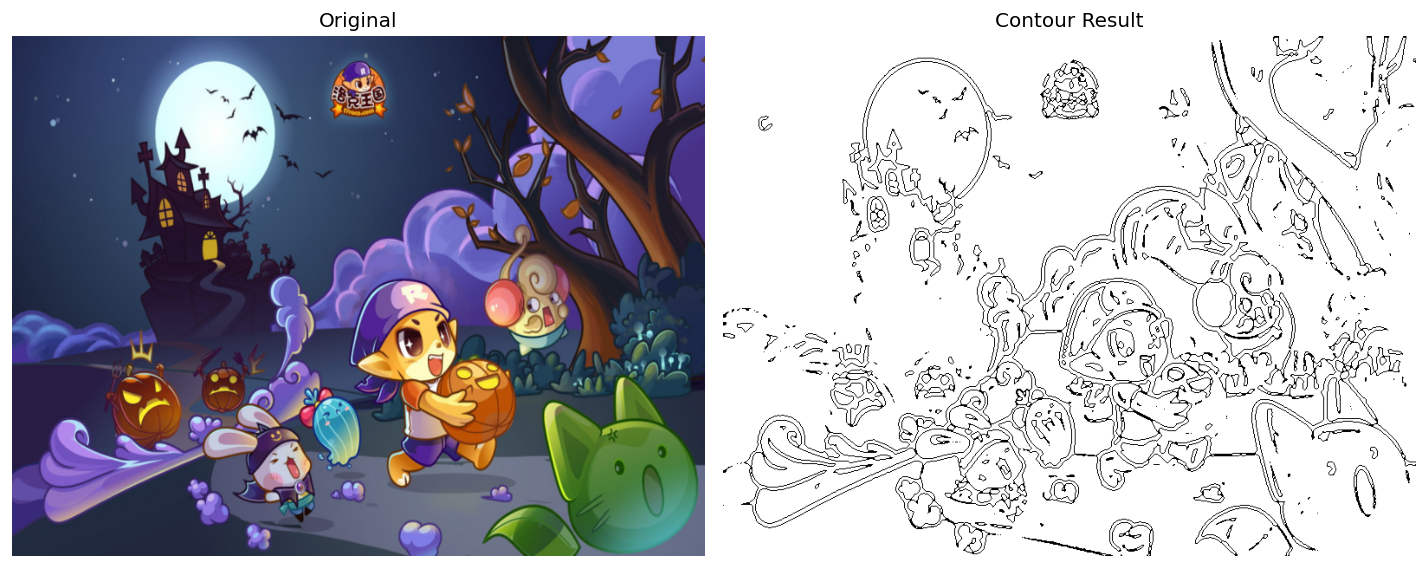

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Contour / Segmentation Pipeline
# Based on EXISTING image
# =========================================================

# Check image

print(type(image))

# Resize
resized = cv2.resize(
    image,
    (800, 600)
)

# Gray
gray = cv2.cvtColor(
    resized,
    cv2.COLOR_RGB2GRAY
)

# Bilateral Filter
smooth = cv2.bilateralFilter(
    gray,
    9,
    75,
    75
)

# Adaptive Threshold
bw = cv2.adaptiveThreshold(
    smooth,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    15,
    4
)

# Morphology
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (3,3)
)

bw = cv2.morphologyEx(
    bw,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=1



)

contours, hierarchy = cv2.findContours(
    bw,
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_SIMPLE
)

# White Canvas
contour_img = np.ones_like(gray) * 255

# Draw Contours
cv2.drawContours(
    contour_img,
    contours,
    -1,
    0,
    1
)
# ---------------------------------------------------------
# Connect Broken Lines
# ---------------------------------------------------------

# ---------------------------------------------------------
# Connect Broken Lines
# ---------------------------------------------------------

# Invert
temp = 255 - contour_img

# Small connection kernel
connect_kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (2,2)
)

# Connect lines
temp = cv2.morphologyEx(
    temp,
    cv2.MORPH_CLOSE,
    connect_kernel,
    iterations=1
)

# Invert back
contour_img = 255 - temp

# Display
# ---------------------------------------------------------
plt.figure(figsize=(12,6))

# Original
plt.subplot(1,2,1)

plt.imshow(resized)

plt.title("Original")

plt.axis("off")


# Final Contour
plt.subplot(1,2,2)

plt.imshow(contour_img, cmap='gray')

plt.title("Contour Result")

plt.axis("off")


plt.tight_layout()

plt.show()

## 선 두께와 Morphology 조절

`thickness`, `open_iter`, `close_iter` 값을 바꾸면 번호 삽입과 색칠 난이도에 맞춰 선을 조절할 수 있습니다.

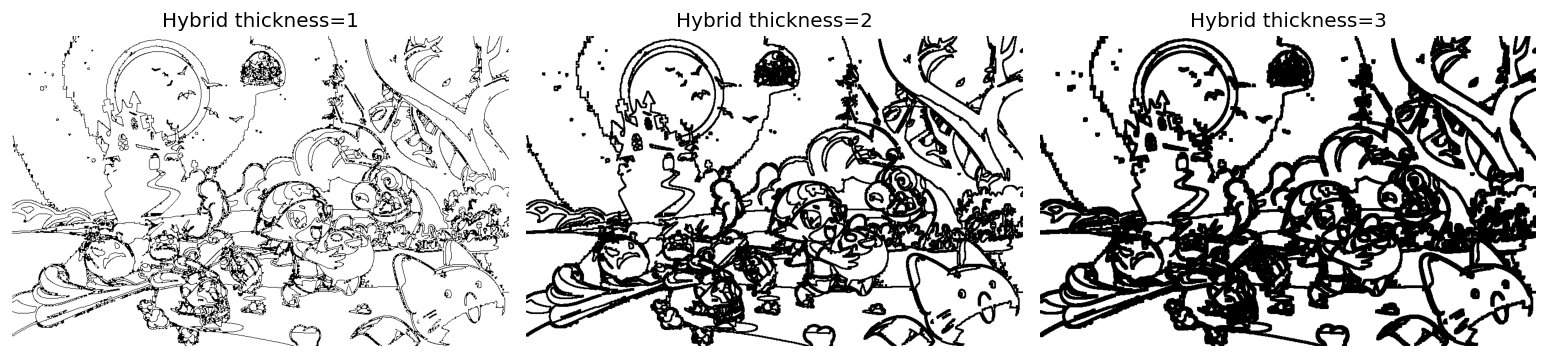

In [8]:
variants = []
for thickness in [1, 2, 3]:
    # thickness가 커질수록 선은 잘 보이지만 색칠 가능한 흰 영역은 줄어듭니다.
    adjusted = clean_edges(hybrid, open_iter=0, close_iter=1, thickness=thickness)
    variants.append((f"Hybrid thickness={thickness}", coloring_line_image(adjusted)))
    save_image_rgb(f"flowersoutput/02_hybrid_thickness_{thickness}.png", coloring_line_image(adjusted))

show_images(variants, cols=3, figsize=(13, 4), cmap="gray", save_path="flowersoutput/02_thickness_compare.png")

## 성능 비교 표

Edge Density는 전체 픽셀 중 경계 픽셀이 차지하는 비율입니다. 너무 낮으면 선이 끊기고, 너무 높으면 색칠 공간이 좁아집니다.

In [9]:
edge_rows = [
    {"algorithm": "Sobel", "runtime_sec": sobel_time, "edge_density": edge_density(sobel_clean), "hci_note": "두꺼운 변화 감지, 질감 노이즈 주의"},
    {"algorithm": "Laplacian", "runtime_sec": lap_time, "edge_density": edge_density(lap_clean), "hci_note": "세부 변화 민감, 작은 노이즈 많음"},
    {"algorithm": "Canny", "runtime_sec": canny_time, "edge_density": edge_density(canny_clean), "hci_note": "선명도와 노이즈 균형 우수"},
    {"algorithm": "Hybrid Color Boundary", "runtime_sec": hybrid_time, "edge_density": edge_density(hybrid_clean), "hci_note": "비슷한 밝기의 색상 경계까지 분리"},
]
print_table(edge_rows)

algorithm             | runtime_sec | edge_density | hci_note            
----------------------+-------------+--------------+---------------------
Sobel                 | 0.0074      | 0.1224       | 두꺼운 변화 감지, 질감 노이즈 주의
Laplacian             | 0.0035      | 0.0653       | 세부 변화 민감, 작은 노이즈 많음 
Canny                 | 0.0034      | 0.1792       | 선명도와 노이즈 균형 우수      
Hybrid Color Boundary | 0.0060      | 0.1228       | 비슷한 밝기의 색상 경계까지 분리  


## 비교 분석

- 선 명확도: Canny가 끊김이 적고 외곽선이 비교적 안정적입니다.
- 노이즈: Laplacian은 작은 밝기 변화에도 민감해 노이즈가 많을 수 있습니다.
- 처리 속도: 세 방법 모두 빠르지만 Sobel/Laplacian이 단순하고 Canny가 약간 더 많은 단계를 가집니다.
- 컬러링북 적합성: Canny + Color Boundary + Closing + 적당한 Dilate 조합이 겹친 색상 영역까지 분리해 가장 적합합니다.

## 최종 결과

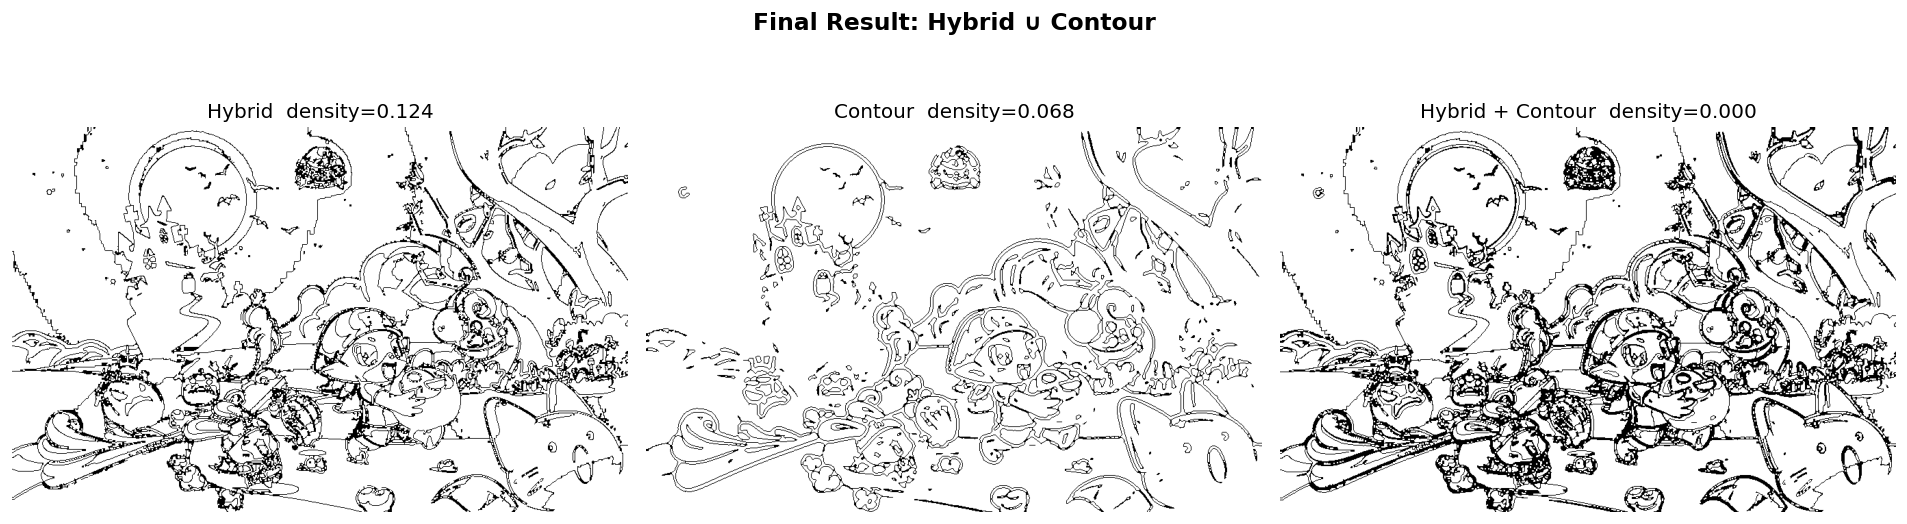

Saved → flowersoutput/02_final_merged_line.png
Saved → flowersoutput/02_final_merged_compare.png


In [6]:
# =========================================================
# 최종 결과: Hybrid ∪ Contour 합산 선화
# =========================================================

# Contour pipeline을 원본 이미지 크기에 맞춰 재실행
_gray    = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
_smooth  = cv2.bilateralFilter(_gray, 9, 75, 75)
_bw      = cv2.adaptiveThreshold(_smooth, 255,
               cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 15, 4)
_kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
_bw      = cv2.morphologyEx(_bw, cv2.MORPH_CLOSE, _kernel, iterations=1)
_contours, _ = cv2.findContours(_bw, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
_cimg    = np.ones_like(_gray) * 255
cv2.drawContours(_cimg, _contours, -1, 0, 1)
_temp    = cv2.morphologyEx(255 - _cimg, cv2.MORPH_CLOSE,
               cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2)), iterations=1)
contour_clean_final = clean_edges(255 - (255 - _temp), open_iter=0, close_iter=1, thickness=1)

# Hybrid + Contour 합산 (bitwise_or)
merged_edges = cv2.bitwise_or(hybrid_clean, contour_clean_final)
merged_edges = thin_edges(merged_edges)   # ← 新增：将合并后变粗的线细化为1像素
merged_edges = clean_edges(merged_edges, open_iter=0, close_iter=0, thickness=1)

save_image_rgb("flowersoutput/02_final_merged_line.png", merged_line)

# 3-way 비교 출력
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(coloring_line_image(hybrid_clean), cmap="gray")
axes[0].set_title(f"Hybrid  density={edge_density(hybrid_clean):.3f}", fontsize=12)
axes[0].axis("off")
axes[1].imshow(coloring_line_image(contour_clean_final), cmap="gray")
axes[1].set_title(f"Contour  density={edge_density(contour_clean_final):.3f}", fontsize=12)
axes[1].axis("off")
axes[2].imshow(merged_line, cmap="gray")
axes[2].set_title(f"Hybrid + Contour  density={edge_density(merged_edges):.3f}", fontsize=12)
axes[2].axis("off")
plt.suptitle("Final Result: Hybrid ∪ Contour", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("flowersoutput/02_final_merged_compare.png", dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved → flowersoutput/02_final_merged_line.png")
print(f"Saved → flowersoutput/02_final_merged_compare.png")